In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

preprocessor = joblib.load("../models/preprocessor.pkl")
best_ridge = joblib.load("../models/ridge_tuned.pkl")

X_train_processed = preprocessor.transform(X_train)

In [2]:
from sklearn.model_selection import cross_val_predict, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_log = cross_val_predict(best_ridge, X_train_processed, y_train, cv=cv)

# Convert both actual and predicted back to dollar scale
oof_preds_dollar = np.expm1(oof_preds_log)
actual_dollar = np.expm1(y_train)

residuals = actual_dollar - oof_preds_dollar

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actual_dollar, oof_preds_dollar)
rmse = np.sqrt(mean_squared_error(actual_dollar, oof_preds_dollar))
r2 = r2_score(actual_dollar, oof_preds_dollar)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.4f}")

MAE: $13,782
RMSE: $20,500
R²: 0.9349


In [4]:
error_df = pd.DataFrame({
    'actual': actual_dollar,
    'predicted': oof_preds_dollar,
    'residual': residuals,
    'abs_residual': residuals.abs()
})

error_df['GrLivArea'] = X_train['GrLivArea'].values
error_df['OverallQual'] = X_train['OverallQual'].values
error_df['Neighborhood'] = X_train['Neighborhood'].values

worst_errors = error_df.sort_values('abs_residual', ascending=False).head(15)
print(worst_errors)

        actual      predicted       residual   abs_residual  GrLivArea  \
496   147000.0  282242.869876 -135242.869876  135242.869876       1795   
967   392000.0  264837.224283  127162.775717  127162.775717       1419   
1143  392500.0  279696.126555  112803.873445  112803.873445       1652   
326   582933.0  473662.249078  109270.750922  109270.750922       2822   
1181  611657.0  505115.172657  106541.827343  106541.827343       2364   
875   395000.0  288960.852490  106039.147510  106039.147510       1973   
710   475000.0  376516.896879   98483.103121   98483.103121       3608   
937   430000.0  524882.444450  -94882.444450   94882.444450       3228   
698   143000.0  237724.745661  -94724.745661   94724.745661       1473   
963   556581.0  462377.357651   94203.642349   94203.642349       2868   
1131  394432.0  304076.549020   90355.450980   90355.450980       1856   
390    82500.0  169445.971119  -86945.971119   86945.971119       1411   
835   440000.0  359674.428100   80325.

In [5]:
underpredictions = error_df[error_df['residual'] > 0]
overpredictions = error_df[error_df['residual'] < 0]

print(f"Underpredictions: {len(underpredictions)} ({len(underpredictions)/len(error_df)*100:.1f}%)")
print(f"Overpredictions: {len(overpredictions)} ({len(overpredictions)/len(error_df)*100:.1f}%)")

print("\nMean underprediction error: $", underpredictions['residual'].mean())
print("Mean overprediction error: $", overpredictions['residual'].mean())

Underpredictions: 644 (52.0%)
Overpredictions: 595 (48.0%)

Mean underprediction error: $ 14046.431335709662
Mean overprediction error: $ -13495.253715770985


In [6]:
expensive = error_df[error_df['actual'] > error_df['actual'].quantile(0.9)]
cheap = error_df[error_df['actual'] < error_df['actual'].quantile(0.1)]

print("Expensive houses (top 10%) - MAE:", expensive['abs_residual'].mean())
print("Cheap houses (bottom 10%) - MAE:", cheap['abs_residual'].mean())
print("Overall MAE:", error_df['abs_residual'].mean())

error_df['pct_error'] = (error_df['abs_residual'] / error_df['actual']) * 100
print("\nExpensive houses - Mean % Error:", error_df.loc[expensive.index, 'pct_error'].mean())
print("Cheap houses - Mean % Error:", error_df.loc[cheap.index, 'pct_error'].mean())

Expensive houses (top 10%) - MAE: 29535.466556753516
Cheap houses (bottom 10%) - MAE: 12421.262728836495
Overall MAE: 13781.741518224988

Expensive houses - Mean % Error: 8.03072181320126
Cheap houses - Mean % Error: 16.389930431418744


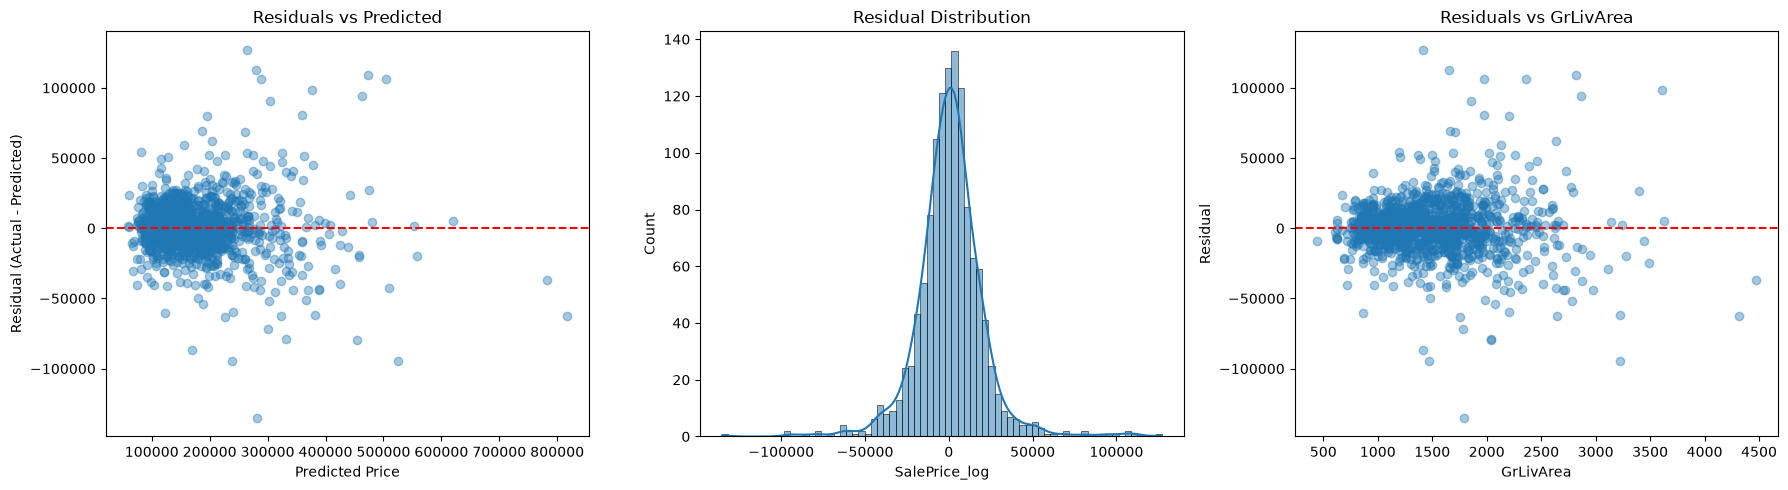

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(oof_preds_dollar, residuals, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")

axes[2].scatter(X_train['GrLivArea'], residuals, alpha=0.4)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel("GrLivArea")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs GrLivArea")

plt.tight_layout()
plt.show()